In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-filter',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_sim',
        '--data_nsample', '500',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.806318, valid=0.217102, test=0.244519
	validation loss decreased (inf -> 0.217102), saving model ...
	epoch 2 losses: train=0.811885, valid=0.068541, test=0.066886
	validation loss decreased (0.217102 -> 0.068541), saving model ...
	epoch 3 losses: train=0.711585, valid=0.067349, test=0.065515
	validation loss decreased (0.068541 -> 0.067349), saving model ...
	epoch 4 losses: train=0.675230, valid=0.063733, test=0.061549
	validation loss decreased (0.067349 -> 0.063733), saving model ...
	epoch 5 losses: train=0.655729, valid=0.061516, test=0.059244
	validation loss decreased (0.063733 -> 0.061516), saving model ...
	epoch 6 losses: train=0.646709, valid=0.061521, test=0.059048
	early stopping counter: 1 out of 10
	epoch 7 losses: train=0.630411, valid=0.065258, test=0.063239
	early stopping counter: 2 out of 10
	epoch 8 losses: train=0.449849, valid=0.034850, test=0.034930
	validation loss decreased (0.061516 -> 0.034850), saving

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

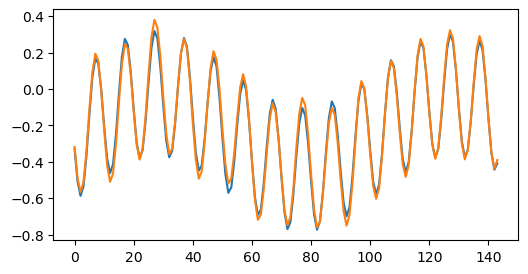

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break